# installing libraries

In [1]:
# !pip install tensorflow==2.16.1 numpy==1.26.4 mediapipe==0.10.11 opencv-python==4.9.0.80 scikit-learn==1.4.2 matplotlib==3.8.2

# importing libraries

In [89]:
import cv2
import mediapipe as mp
import numpy as np
from keras.src.backend.jax.numpy import expand_dims
from matplotlib import pyplot as plt
import os
from collections import deque
import time

# Mediapipe processing

In [3]:
mp_drawing = mp.solutions.drawing_utils
mp_holistic = mp.solutions.holistic

In [4]:
def mediapipe_detection(image, holistic):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = holistic.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results

In [5]:
def draw_landmarks(image, results):
        #drawing right hand landmarks
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                                  mp_drawing.DrawingSpec(color=(255, 0, 0), thickness=2, circle_radius=2),
                                  mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=1, circle_radius=1))
        #drawing left hand landmarks
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
                                  mp_drawing.DrawingSpec(color=(255, 0, 0), thickness=2, circle_radius=2),
                                  mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=1, circle_radius=1))

In [6]:
def extract_keypoints(results):
    left = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(63)
    right = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(63)
    return np.concatenate([left, right])

# Preparing folders

In [7]:
DATA_PATH = os.path.join('ProjectData')
actions = np.array(['Hello', 'Thank you', 'I love you', 'Me', 'Again'])
sequence_length = 30
#number of videos * 30 frames each * 5 actions * 126 keypoints
# Hello 200, Thank you 200, I love you 220, Me 220, Again 200 videos

# Data collection

In [8]:
# # data collection
# cap = cv2.VideoCapture(0)
# with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
#     for action in actions:
#         for sequence in range(no_sequences):
#             for frame_num in range(sequence_length):
#                 ret, frame = cap.read()
#                 if not ret:
#                     continue
#                 image, results = mediapipe_detection(frame, holistic)
#                 draw_landmarks(image, results)
#                 #logic for collecting data, to take a break between each video
#                 if frame_num == 0:
#                     cv2.putText(image, 'STARTING COLLECTION', (120,200),
#                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
#                     cv2.putText(image, f'Collecting frames for {action} Video Number {sequence}', (15,12),
#                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
#                     cv2.imshow('feed', image)
#                     cv2.waitKey(100)
#                     time.sleep(3)
#                 else:
#                     cv2.putText(image, f'Collecting frames for {action} Video Number {sequence}', (15,12),
#                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
#
#
#
#                 keypoints = extract_keypoints(results)
#                 npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
#                 np.save(npy_path, keypoints)
#
#                 cv2.imshow('feed', image)
#                 if cv2.waitKey(1) & 0xFF == ord('q'):
#                     break
#             if cv2.waitKey(1) & 0xFF == ord('q'):
#                 break
#     cap.release()
#     cv2.destroyAllWindows()

In [10]:
# cap.release()
# cv2.destroyAllWindows()

# Data preprocessing

In [8]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

In [9]:
label_map = {label:num for num, label in enumerate(actions)}
print(label_map)

{'Hello': 0, 'Thank you': 1, 'I love you': 2, 'Me': 3, 'Again': 4}


In [13]:
# sequences, labels = [], []
#
# for action in actions:
#     action_path = os.path.join(DATA_PATH, action)
#     for sequence in sorted(os.listdir(action_path), key=lambda x: int(x)):
#         seq_path = os.path.join(action_path, sequence)
#         window = []
#         for frame_num in range(sequence_length):
#             res = np.load(os.path.join(seq_path, f"{frame_num}.npy"))
#             window.append(res[132:])
#
#         sequences.append(window)
#         labels.append(label_map[action])


In [14]:
# X = np.array(sequences)
# Y = to_categorical(labels).astype(int)
# np.save("X_data.npy", X)
# np.save("Y_labels.npy", Y)
# print(X.shape)
# print(Y.shape)

(1040, 30, 126)
(1040, 5)


In [10]:
X = np.load("X_data.npy")
Y = np.load("Y_labels.npy")

In [11]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, shuffle=True, random_state=42)

In [12]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

In [13]:
from sklearn.utils.class_weight import compute_class_weight
labels_int = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_int),
    y=labels_int
)
class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: 1.018181818181818, 1: 1.12, 2: 0.9516339869281045, 3: 0.9273885350318471, 4: 1.0041379310344827}


In [14]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Building model

In [15]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(30,126)))
model.add(Dropout(0.2))
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

D:\coding projects\python\SignLanguage\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [35]:
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(x_test, y_test),
    shuffle=True,
    class_weight = class_weights,
    callbacks= [early_stopping]
)


Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - categorical_accuracy: 0.3462 - loss: 1.4719 - val_categorical_accuracy: 0.3237 - val_loss: 1.3696
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - categorical_accuracy: 0.4602 - loss: 1.2448 - val_categorical_accuracy: 0.5353 - val_loss: 1.0652
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - categorical_accuracy: 0.5879 - loss: 1.0044 - val_categorical_accuracy: 0.6090 - val_loss: 0.9331
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - categorical_accuracy: 0.6195 - loss: 0.8816 - val_categorical_accuracy: 0.4583 - val_loss: 1.1933
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - categorical_accuracy: 0.6003 - loss: 0.8783 - val_categorical_accuracy: 0.6571 - val_loss: 0.7552
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - categorical_accuracy: 0.6703 - loss: 0.7401 - val_categorical_accuracy: 0.6667 - val_loss: 0.8255
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - categorical_accuracy: 0.7143 - los

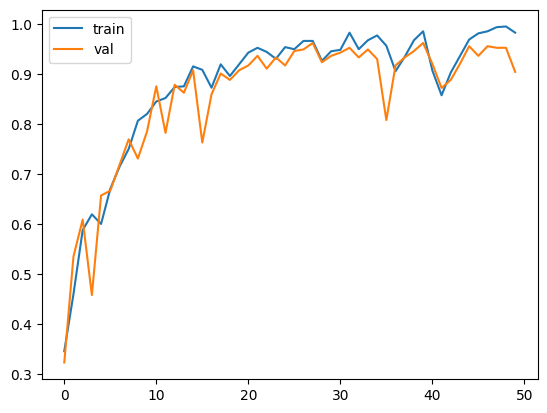

In [36]:
plt.plot(history.history['categorical_accuracy'], label='train')
plt.plot(history.history['val_categorical_accuracy'], label='val')
plt.legend()
plt.show()

# saving model

In [55]:
# model.save("SignLanguage1.h5")

In [17]:
model.load_weights("SignLanguage1.h5")

# Evaluation

In [18]:
model.evaluate(x_test, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - categorical_accuracy: 0.9615 - loss: 0.1317


[0.1317099928855896, 0.9615384340286255]

In [23]:
res = model.predict(x_test)
print(res[0])

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step
[9.9518883e-01 1.0764168e-04 4.6199081e-03 7.3819720e-05 9.7678503e-06]


In [24]:
np.sum(res[0])

0.99999994

In [25]:
actions[np.argmax(res[10])]

'Me'

In [26]:
actions[np.argmax(y_test[10])]

'Me'

In [27]:
res.shape

(312, 5)

In [23]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=actions))


10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step
              precision    recall  f1-score   support

       Hello       0.98      0.96      0.97        57
   Thank you       0.93      0.96      0.94        70
  I love you       0.97      0.94      0.95        67
          Me       0.97      0.97      0.97        63
       Again       0.96      0.98      0.97        55

    accuracy                           0.96       312
   macro avg       0.96      0.96      0.96       312
weighted avg       0.96      0.96      0.96       312



In [30]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
yhat = model.predict(x_test)
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()
print(multilabel_confusion_matrix(ytrue, yhat))

# [[TN, FP],
# [FN, TP]]


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
[[[254   1]
  [  2  55]]

 [[237   5]
  [  3  67]]

 [[243   2]
  [  4  63]]

 [[247   2]
  [  2  61]]

 [[255   2]
  [  1  54]]]


In [31]:
accuracy_score(ytrue, yhat)

0.9615384615384616

# Real time testing

In [90]:
frame_skip = 2
frame_count = 0
display_action = ""
display_confidence = 0.0
sequence = deque(maxlen=30)
predictions = deque(maxlen=10)

cap = cv2.VideoCapture(0)

with mp_holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5) as holistic:

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        image, results = mediapipe_detection(frame, holistic)
        draw_landmarks(image, results)

        keypoints = extract_keypoints(results)
        sequence.append(keypoints)


        if len(sequence) == 30 and frame_count % frame_skip == 0:

            res = model.predict(np.expand_dims(sequence, axis=0), verbose=0)[0]
            action = actions[np.argmax(res)]
            confidence = np.max(res)

            predictions.append(action)
            print(f"{action} ---> {confidence:.2f}")
            if predictions.count(action) >= 6 and confidence > 0.85:
                display_action = action
                display_confidence = confidence
        if display_action != "":
            cv2.putText(
                image,
                f'{display_action} ({display_confidence:.2f})',
                (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0, 0, 255),
                2
            )
            # print(np.array(sequence).shape)
        cv2.imshow('Sign Language Recognition', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()


Me ---> 0.96
Me ---> 0.96
Me ---> 0.96
Me ---> 0.96
Me ---> 0.96
Me ---> 0.94
Me ---> 0.67
Hello ---> 0.98
Hello ---> 0.99
Hello ---> 0.99
Hello ---> 1.00
Hello ---> 1.00
Hello ---> 1.00
Hello ---> 1.00
Hello ---> 1.00
Hello ---> 1.00
Hello ---> 1.00
Hello ---> 1.00
Hello ---> 1.00
Hello ---> 0.99
Hello ---> 0.99
Hello ---> 0.98
Hello ---> 0.97
Hello ---> 0.92
Hello ---> 0.69
I love you ---> 0.76
I love you ---> 0.95
I love you ---> 0.98
I love you ---> 1.00
I love you ---> 1.00
I love you ---> 1.00
I love you ---> 1.00
I love you ---> 1.00
I love you ---> 1.00
I love you ---> 1.00
I love you ---> 1.00
I love you ---> 0.99
I love you ---> 0.98
I love you ---> 0.91
I love you ---> 0.55
Hello ---> 0.89
Hello ---> 0.97
Hello ---> 0.98
Hello ---> 0.97
Hello ---> 0.91
Me ---> 0.99
Me ---> 0.99
Me ---> 0.99
Me ---> 0.99
Me ---> 1.00
Me ---> 1.00
Me ---> 0.99
Me ---> 0.99
Me ---> 0.99
Me ---> 0.96
Me ---> 0.85
Again ---> 0.71
Again ---> 0.96
Again ---> 0.99
Again ---> 1.00
Again ---> 1.00
Aga

In [24]:
cap.release()
cv2.destroyAllWindows()

In [93]:
frame_skip = 2
frame_count = 0
display_action = ""
display_confidence = 0.0
sequence = deque(maxlen=30)
predictions = deque(maxlen=10)

cap = cv2.VideoCapture(0)

with mp_holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5) as holistic:

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (640, 480))
        frame_count += 1

        image, results = mediapipe_detection(frame, holistic)
        draw_landmarks(image, results)

        # ✅ Check if at least one hand is detected
        hands_detected = (
            results.left_hand_landmarks is not None or
            results.right_hand_landmarks is not None
        )

        if hands_detected:
            keypoints = extract_keypoints(results)
            sequence.append(keypoints)

            if len(sequence) == 30:
                res = model.predict(np.expand_dims(sequence, axis=0), verbose=0)[0]
                action = actions[np.argmax(res)]
                confidence = np.max(res)

                predictions.append(action)

                print(f"{action} ---> {confidence:.2f}")

                if confidence > 0.8:
                    display_action = action
                    display_confidence = confidence
        else:
            # 🚫 No hands detected → clear sequence and reset prediction
            sequence.clear()
            predictions.clear()
            display_action = "no action detected"
            display_confidence = 0.0

        # Display prediction
        if display_action != "":
            cv2.putText(
                image,
                f'{display_action} ({display_confidence:.2f})',
                (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0, 0, 255),
                2
            )

        cv2.imshow('Sign Language Recognition', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()
